# Lab 4: N-gram Language Models with Smoothing

Builds **unigram / bigram / trigram / quadgram** language models on the Hindi corpus from Lab 3.

Five smoothing strategies:
1. Unsmoothed (raw counts)
2. Add-1 (Laplace)
3. Add-K (K = 0.1)
4. Interpolated (Recursive interpolation with uniform 1/V backoff for unigrams)
5. Kneser-Ney (d = 0.75)

Metric: **Perplexity** on the dev and test sets.

In [6]:
# Cell 1 - Imports & reproduce train/dev/test split from Lab 3
import os, re, random, math
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)

CORPUS_FILE = 'hindi_1_1m_sentences.txt'

def sentence_tokenize(text):
    if not text or not text.strip():
        return []
    text = re.sub(r'\\s+', ' ', text.strip())
    chunks = re.split(r'(?<=[\u0964\u0965.!?])\\s+', text)
    return [c.strip() for c in chunks
            if len(c.strip()) >= 3 and not re.fullmatch(r'[\\s\\W_]+', c)]

if not os.path.exists(CORPUS_FILE):
    import urllib.request
    DATA_URL = 'https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main/data/hi-1.txt'
    TARGET   = 1_100_000
    print(f'Downloading corpus (target {TARGET} sentences)...')
    n = 0
    with urllib.request.urlopen(urllib.request.Request(DATA_URL)) as resp, \
         open(CORPUS_FILE, 'w', encoding='utf-8') as fout:
        for raw in resp:
            for sent in sentence_tokenize(raw.decode('utf-8', 'ignore')):
                fout.write(sent + '\\n')
                n += 1
                if n >= TARGET: break
            if n >= TARGET: break
    print(f'Done - {n} sentences written.')

with open(CORPUS_FILE, encoding='utf-8') as f:
    all_sentences = [l.strip() for l in f if l.strip()]
print(f'Total sentences loaded: {len(all_sentences):,}')

def length_balanced_split(sentences, dev_size=1000, test_size=1000, seed=SEED):
    rng = random.Random(seed)
    sorted_sents = sorted(sentences, key=lambda s: len(s.split()))
    total  = len(sorted_sents)
    decile = total // 10
    dper   = dev_size  // 10
    tper   = test_size // 10
    dev_set, test_set, train_set = [], [], []
    for d in range(10):
        sl = sorted_sents[d*decile : (d+1)*decile if d < 9 else total]
        rng.shuffle(sl)
        dev_set.extend(sl[:dper])
        test_set.extend(sl[dper : dper + tper])
        train_set.extend(sl[dper + tper:])
    return train_set, dev_set, test_set

train_sents, dev_sents, test_sents = length_balanced_split(all_sentences)
print(f'Train: {len(train_sents):,} | Dev: {len(dev_sents):,} | Test: {len(test_sents):,}')

Total sentences loaded: 1,100,000
Train: 1,098,000 | Dev: 1,000 | Test: 1,000


In [7]:
# Cell 2 - Build vocabulary and n-gram counts

BOS = '<s>'
EOS = '</s>'
UNK = '<unk>'

def tokenise(sentence):
    return sentence.strip().split()

raw_counts = Counter()
for sent in train_sents:
    raw_counts.update(tokenise(sent))

vocab = {w for w, c in raw_counts.items() if c >= 2}
vocab |= {BOS, EOS, UNK}
V = len(vocab)
print(f'Vocabulary size (freq >= 2): {V:,}')

def prepare(sentence, n):
    tokens = [w if w in vocab else UNK for w in tokenise(sentence)]
    return [BOS] * (n - 1) + tokens + [EOS]

MAX_N = 4
ngram_counts   = {}
context_counts = {}

for n in range(1, MAX_N + 1):
    nc = Counter()
    cc = Counter()
    for sent in train_sents:
        tokens = prepare(sent, n)
        for i in range(n - 1, len(tokens)):
            gram = tuple(tokens[i - n + 1 : i + 1])
            ctx  = gram[:-1]
            nc[gram] += 1
            cc[ctx]  += 1
    ngram_counts[n]   = nc
    context_counts[n] = cc
    print(f'  N={n}: {len(nc):,} n-grams, {len(cc):,} contexts')

Vocabulary size (freq >= 2): 187,133
  N=1: 187,132 n-grams, 1 contexts
  N=2: 3,664,459 n-grams, 187,132 contexts
  N=3: 10,178,387 n-grams, 3,637,941 contexts
  N=4: 14,824,665 n-grams, 9,978,830 contexts


In [8]:
# Cell 3 - Language model classes (all 5 smoothing methods)

class NgramLM:
    """Unsmoothed MLE."""
    name = 'Unsmoothed'

    def __init__(self, n):
        self.n  = n
        self.nc = ngram_counts[n]
        self.cc = context_counts[n]

    def log_prob(self, gram):
        ctx  = gram[:-1]
        c_ng = self.nc.get(gram, 0)
        c_ct = self.cc.get(ctx,  0)
        if c_ng == 0 or c_ct == 0:
            return -math.inf
        return math.log2(c_ng / c_ct)


class AddKLM(NgramLM):
    """Add-K smoothing; k=1 gives Laplace."""
    def __init__(self, n, k=1):
        super().__init__(n)
        self.k    = k
        self.name = 'Add-1 (Laplace)' if k == 1 else f'Add-K (k={k})'

    def log_prob(self, gram):
        ctx  = gram[:-1]
        c_ng = self.nc.get(gram, 0) + self.k
        c_ct = self.cc.get(ctx,  0) + self.k * V
        return math.log2(c_ng / c_ct)


class InterpolatedLM:
    """Interpolated Smoothing with recursive backoff and uniform 1/V for unigrams."""
    name = 'Interpolated'

    def __init__(self, n, lam=0.8):
        self.n   = n
        self.lam = lam

    def _prob(self, gram):
        k = len(gram)
        ctx = gram[:-1]
        c_ng = ngram_counts[k].get(gram, 0)
        c_ctx = context_counts[k].get(ctx, 0)
        p_raw = c_ng / c_ctx if c_ctx > 0 else 0.0

        if k == 1:
            return self.lam * p_raw + (1 - self.lam) * (1 / V)
        else:
            return self.lam * p_raw + (1 - self.lam) * self._prob(gram[1:])

    def log_prob(self, gram):
        return math.log2(max(self._prob(gram), 1e-300))


class KneserNeyLM:
    """Interpolated Kneser-Ney smoothing (d=0.75)."""
    name = 'Kneser-Ney (d=0.75)'

    def __init__(self, n, d=0.75):
        self.n  = n
        self.d  = d
        self.cont = {}
        self.right_ext = {}
        # Precompute continuation and right extension counts for O(1) lookups
        for k in range(1, n + 1):
            ct = Counter()
            rext = Counter()
            for gram in ngram_counts[k]:
                ct[gram[-1:]] += 1       # unique left contexts for a word
                rext[gram[:-1]] += 1     # unique right extensions for a context
            self.cont[k] = ct
            self.right_ext[k] = rext
            
        # total continuation count (for unigram denominator)
        self.total_cont = sum(self.cont[1].values())

    def _pkn(self, gram):
        k   = len(gram)
        ctx = gram[:-1]
        d   = self.d

        if k == 1:
            return self.cont[1].get(gram, 0) / max(self.total_cont, 1)

        c_ng  = ngram_counts[k].get(gram, 0)
        c_ctx = context_counts[k].get(ctx, 0)
        if c_ctx == 0:
            return self._pkn(gram[1:])

        # number of distinct right-extensions of ctx at order k (now O(1))
        n_ctx = self.right_ext[k].get(ctx, 0)
        lam   = (d * n_ctx) / c_ctx
        return max(c_ng - d, 0) / c_ctx + lam * self._pkn(gram[1:])

    def log_prob(self, gram):
        return math.log2(max(self._pkn(gram), 1e-300))


print('All model classes ready (Optimised Kneser-Ney).')

All model classes ready (Optimised Kneser-Ney).


In [9]:
# Cell 4 - Perplexity evaluation

def perplexity(model, sentences, n, max_sents=300):
    log_sum = 0.0
    tok_cnt = 0
    for sent in sentences[:max_sents]:
        tokens = prepare(sent, n)
        for i in range(n - 1, len(tokens)):
            gram = tuple(tokens[i - n + 1 : i + 1])
            lp   = model.log_prob(gram)
            log_sum += lp if lp != -math.inf else -40
            tok_cnt += 1
    return 2 ** (-log_sum / tok_cnt)


results = {}

for n in range(1, MAX_N + 1):
    models = [
        NgramLM(n),
        AddKLM(n, k=1),
        AddKLM(n, k=0.1),
        InterpolatedLM(n),
        KneserNeyLM(n, d=0.75),
    ]
    print(f'\n=== N = {n} ===')
    for m in models:
        pp_dev  = perplexity(m, dev_sents,  n)
        pp_test = perplexity(m, test_sents, n)
        results[(n, m.name, 'dev')]  = pp_dev
        results[(n, m.name, 'test')] = pp_test
        print(f'  {m.name:<25}  dev={pp_dev:>10.2f}  test={pp_test:>10.2f}')

print('\nEvaluation complete.')


=== N = 1 ===
  Unsmoothed                 dev=   1460.59  test=   1586.23
  Add-1 (Laplace)            dev=   1463.16  test=   1587.46
  Add-K (k=0.1)              dev=   1460.75  test=   1586.23
  Interpolated               dev=   1667.44  test=   1789.64
  Kneser-Ney (d=0.75)        dev= 187132.00  test= 187132.00

=== N = 2 ===
  Unsmoothed                 dev=   1851.06  test=   2158.61
  Add-1 (Laplace)            dev=   2783.94  test=   3184.10
  Add-K (k=0.1)              dev=    943.71  test=   1080.29
  Interpolated               dev=    290.94  test=    318.57
  Kneser-Ney (d=0.75)        dev=    354.00  test=    387.22

=== N = 3 ===
  Unsmoothed                 dev= 405018.39  test= 822001.22
  Add-1 (Laplace)            dev=  23410.70  test=  26026.34
  Add-K (k=0.1)              dev=   8475.69  test=  10080.38
  Interpolated               dev=    319.00  test=    394.87
  Kneser-Ney (d=0.75)        dev=    276.83  test=    336.86

=== N = 4 ===
  Unsmoothed             

Perplexity on DEV set
Smoothing                  N=1          N=2          N=3          N=4        
-----------------------------------------------------------------------------
Unsmoothed                    1460.59     1851.06   405018.39  10000000.00
Add-1 (Laplace)               1463.16     2783.94    23410.70    53116.75
Add-K (k=0.1)                 1460.75      943.71     8475.69    29053.63
Interpolated                  1667.44      290.94      319.00      721.77
Kneser-Ney (d=0.75)         187132.00      354.00      276.83      289.76


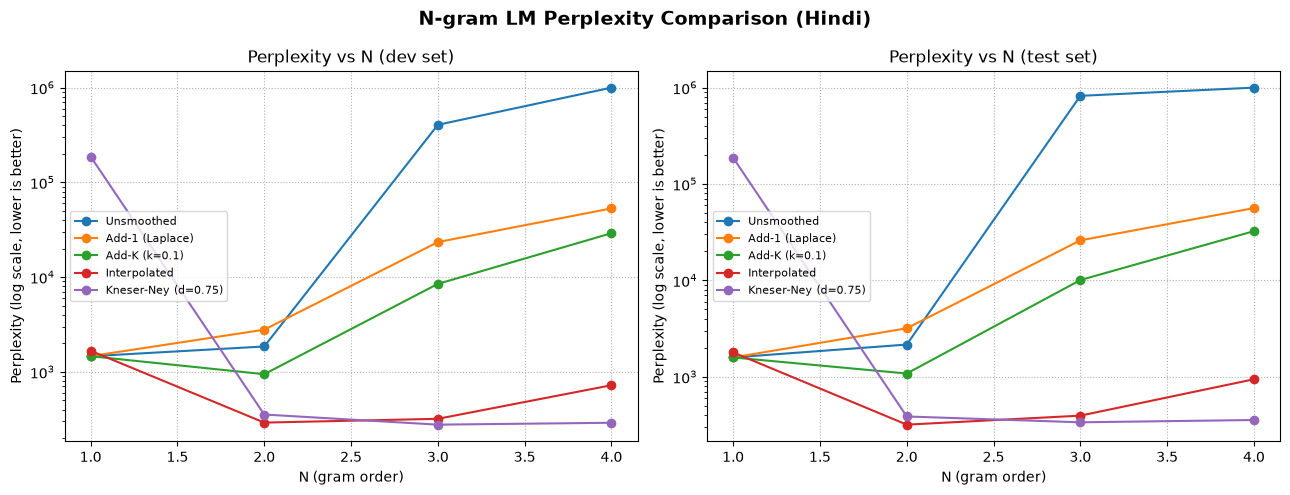

Plot saved to ngram_perplexity_comparison.png


In [10]:
# Cell 5 - Comparison table and perplexity plot

smoothing_names = [
    'Unsmoothed',
    'Add-1 (Laplace)',
    'Add-K (k=0.1)',
    'Interpolated',
    'Kneser-Ney (d=0.75)',
]
N_values = [1, 2, 3, 4]

# Summary table
print('Perplexity on DEV set')
header = f"{'Smoothing':<25}" + ''.join(f'  N={n:<9}' for n in N_values)
print(header)
print('-' * len(header))
for sname in smoothing_names:
    row = f'{sname:<25}'
    for n in N_values:
        pp = results.get((n, sname, 'dev'), float('nan'))
        row += f'  {min(pp, 1e7):>10.2f}'
    print(row)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split, ax in zip(['dev', 'test'], axes):
    for sname in smoothing_names:
        pp_vals = [min(results.get((n, sname, split), float('nan')), 1e6)
                   for n in N_values]
        ax.plot(N_values, pp_vals, 'o-', label=sname)
    ax.set_title(f'Perplexity vs N ({split} set)')
    ax.set_xlabel('N (gram order)')
    ax.set_ylabel('Perplexity (log scale, lower is better)')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':')

plt.suptitle('N-gram LM Perplexity Comparison (Hindi)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ngram_perplexity_comparison.png', dpi=120)
plt.show()
print('Plot saved to ngram_perplexity_comparison.png')